#### **Importing Packages**

In [47]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import plotly.graph_objects as go  
import dash
from dash import dcc, html, Input, Output

In [48]:
data= pd.read_csv('AusApparalSales4thQrt2020.csv')

### 1. Data wrangling

In [49]:
data.head(5) 

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


The dataset consists of 6 columns: 4 categorical (object-type) columns—Date, Time, State, and Group—and 2 integer columns—Unit (number of items sold) and Sales (total revenue per transaction). Although the Date column is currently stored as an object type, it should be converted to datetime format to enable time-based analysis. All 7,560 rows are complete with no missing values in any column, as verified using isnull().sum(). The Sales column is appropriately maintained as an integer type, given that values range from around 5,000 to 162,500 per transaction and decimal precision is unnecessary at this scale.

Convert Date to datetime format:

In [51]:
data['Date'] = pd.to_datetime(data['Date'], format='%d-%b-%Y')


In [52]:
print("Check for missing values")
print(data.isnull().sum()) 


Check for missing values
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64


The output above confirms the data having no column with missing data.

### Recommendations for Treating Missing and Incorrect Data:

If the dataset contains missing values, the following strategies are recommended:

- For **numerical data** that is **not skewed**, impute missing values using the **mean**. However, if the data is **skewed** or influenced by outliers, it is better to impute missing values with the **median**.
- For **categorical data**, the **mode** should be used to fill in missing values.

Fortunately, this dataset does not contain any missing values at the moment. In cases where there are rows with a significant amount of missing data across multiple features, it may be appropriate to drop these rows, especially if the dataset is large and removing a few columns will not have a significant impact.
 


In [53]:
print(data['Group'].unique())

[' Kids' ' Men' ' Women' ' Seniors']


In [54]:
for column in data.columns[1:4]:
    print(f'"{column}" column has the following uniques entries : \n {data[column].unique()}\n')  

"Time" column has the following uniques entries : 
 [' Morning' ' Afternoon' ' Evening']

"State" column has the following uniques entries : 
 [' WA' ' NT' ' SA' ' VIC' ' QLD' ' NSW' ' TAS']

"Group" column has the following uniques entries : 
 [' Kids' ' Men' ' Women' ' Seniors']



The unique entries in each categorical column appear to be consistent. Below is a summary of the unique entries found in the relevant columns:

- **Time column**: The entries in the "Time" column are consistent with only three unique values: "Morning", "Afternoon", and "Evening". There are no issues with incorrect spelling or format (e.g., no instances of "Morning" and "morniNG").
  
- **State column**: The "State" column has six unique values: "WA", "NT", "SA", "VIC", "QLD", "NSW", and "TAS". All entries follow the same format and are consistent.

- **Group column**: The "Group" column has four unique values: "Kids", "Men", "Women", and "Seniors". The entries are consistent and correctly formatted.

Overall, the categorical columns are properly formatted and free of spelling inconsistencies or data entry errors.

### Normalization vs. Standardization

At this stage of **data wrangling**, it is not essential to scale the data yet. Scaling—whether through normalization or standardization—is best applied later, during **model preparation**, to enhance the performance of machine learning algorithms.

However, **normalization** is the preferred technique for this dataset because:
- The data contains only **positive values**, making normalization (scaling to a range between 0 and 1) more suitable.
- **Distance-based algorithms** (e.g., KNN, SVM) benefit significantly from normalized features on a common scale.
- Normalization avoids the introduction of **negative values**, which standardization might produce for values below the mean.

>  **Note**: Applying normalization too early can **distort descriptive statistics** and affect data interpretation during exploratory analysis and visualization. Therefore, normalization should be **deferred** until model training or specific visualizations require it.


Grouping the data

In [55]:
data.groupby('Group')['Group'].value_counts()

Group
Kids       1890
Men        1890
Seniors    1890
Women      1890
Name: count, dtype: int64

In [56]:
data.groupby('State')['State'].value_counts()

State
NSW    1080
NT     1080
QLD    1080
SA     1080
TAS    1080
VIC    1080
WA     1080
Name: count, dtype: int64

In [57]:
data.groupby('Time')['Time'].value_counts()

Time
Afternoon    2520
Evening      2520
Morning      2520
Name: count, dtype: int64

### GroupBy Analysis Summary

##### Key Findings
- **Balanced Distribution** observed across all categorical features:
  - `Group`: Kids, Men, Women, Seniors (1,890 records each)
  - `State`: All states (1,080 records each)
  - `Time`: Morning, Afternoon, Evening (2,520 records each)

##### Implications
  **Advantages for Machine Learning:**
- Eliminates need for class balancing techniques (SMOTE, ADASYN)
- Prevents model bias toward dominant categories
- Simplifies cross-validation and train-test splits

  **Data Characteristics Note:**
- Perfect uniformity suggests synthetic/curated data
- Real-world datasets typically show natural imbalances

##### Recommendations
 **For Data Wrangling:**
   - No additional balancing required
   - More in-depth aggregated group-by analysis will be conducted during the data analysis stage, such as identifying the groups with the highest and lowest sales.

   

# Data analysis

Descriptive Statistics

In [58]:
print(f"The descriptive statistics of the dataset is as follows: \n") 
data.describe()

The descriptive statistics of the dataset is as follows: 



,Date,Unit,Sales
count,7560,7560.000000,7560.000000
mean,2020-11-15 04:00:00.000000256,18.005423,45013.558201
min,2020-10-01 00:00:00,2.000000,5000.000000
25%,2020-10-23 00:00:00,8.000000,20000.000000
50%,2020-11-15 12:00:00,14.000000,35000.000000
75%,2020-12-08 00:00:00,26.000000,65000.000000
max,2020-12-30 00:00:00,65.000000,162500.000000
std,NaN,12.901403,32253.506944


#### Key Insights

1. **Central Tendency**:
   - The average transaction involves **18 units** sold
   - Median sales amount is **$35,000** (50% below this value)

2. **Data Spread**:
   - High standard deviation in Sales (**$32,253.51**) indicates significant variability
   - Unit sales range from **2 to 65** per transaction
   - Sales range from **$5,000 to $162,500**

3. **Distribution Shape**:
   - Mean > Median for both features → **Right-skewed distribution**
   - 25% of transactions sell ≤8 units (vs 75% sell ≤26 units)
   - Similar pattern in sales amounts (25% ≤$20k vs 75% ≤$65k)

What is the group with the highest sales and the group with the lowest?

In [59]:
print("Summary Statistics of Sales by Group:\n")
display(data.groupby('Group')['Sales'].describe())

Summary Statistics of Sales by Group:



,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
Kids,1890.0,45011.904762,31871.491085,5000.0,20000.0,35000.0,65000.0,162500.0
Men,1890.0,45370.370370,32177.180712,5000.0,20000.0,35000.0,65000.0,160000.0
Seniors,1890.0,44464.285714,32195.360017,5000.0,20000.0,35000.0,62500.0,162500.0
Women,1890.0,45207.671958,32781.639869,5000.0,20000.0,35000.0,67500.0,162500.0


In [60]:
group_sales =(data.groupby('Group')['Sales'].sum())

print(group_sales)

Group
Kids       85072500
Men        85750000
Seniors    84037500
Women      85442500
Name: Sales, dtype: int64


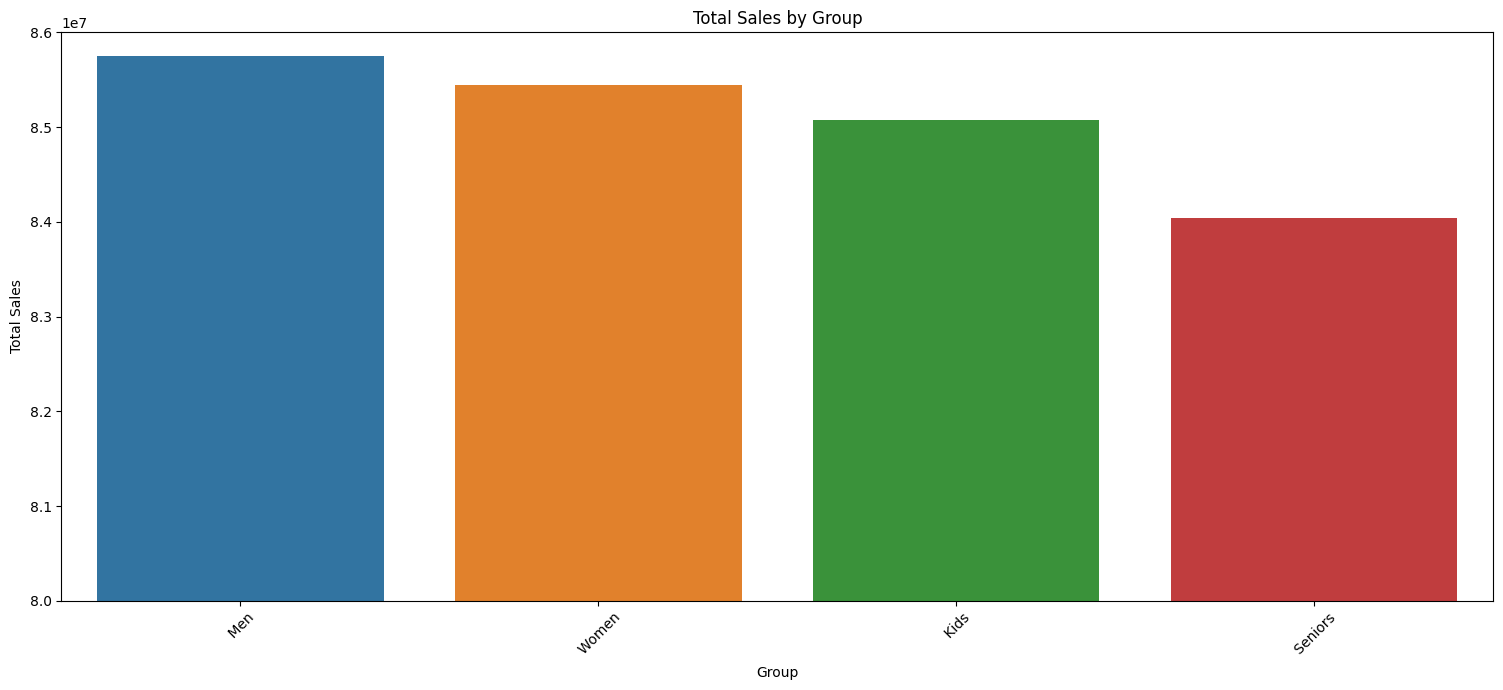

In [61]:

group_sales = data.groupby('Group')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(15, 7))
sns.barplot(x=group_sales.index, y=group_sales.values, hue=group_sales.index)
plt.title('Total Sales by Group')
plt.xlabel('Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(80_000_000, 86_000_000)

plt.show()


**Group Sales Summary**

The customer groups exhibit similar sales volumes, but there are still measurable differences. The group with the highest total sales is Men, with $85,750,000, while the group with the lowest total sales is Seniors, with $84,037,500

In [62]:
data.Date.min(), data.Date.max()

(Timestamp('2020-10-01 00:00:00'), Timestamp('2020-12-30 00:00:00'))

Store weekly, monthly, and quarterly data for analysis 

In [63]:
weekly_report = data.groupby([pd.Grouper(key='Date', freq='W'),'State'])[['Sales','Unit']].sum()

monthly_report = data.groupby([pd.Grouper(key='Date', freq='ME'),'State'])[['Sales','Unit']].sum()

quarterly_report = data.groupby([pd.Grouper(key='Date', freq='QE'),'State'])[['Sales','Unit']].sum()


In [64]:
print(data['Date'].min(), data['Date'].max())


2020-10-01 00:00:00 2020-12-30 00:00:00


#### Quartely Report 

In [65]:
len(quarterly_report)

7

In [66]:
quarterly_report

Sales   Unit
Date       State                  
2020-12-31 NSW     74970000  29988
           NT      22580000   9032
           QLD     33417500  13367
           SA      58857500  23543
           TAS     22760000   9104
           VIC    105565000  42226
           WA      22152500   8861

In [67]:
len(monthly_report)

21

In [68]:
display(weekly_report[:10])

Sales  Unit
Date       State               
2020-10-04 NSW    3382500  1353
           NT     1052500   421
           QLD    1627500   651
           SA     2542500  1017
           TAS    1052500   421
           VIC    4355000  1742
           WA     1032500   413
2020-10-11 NSW    5892500  2357
           NT     1937500   775
           QLD    2545000  1018

,Date,State,Sales,Unit
5,2020-12-31,VIC,105565000,42226
0,2020-12-31,NSW,74970000,29988
3,2020-12-31,SA,58857500,23543
2,2020-12-31,QLD,33417500,13367
4,2020-12-31,TAS,22760000,9104
1,2020-12-31,NT,22580000,9032
6,2020-12-31,WA,22152500,8861


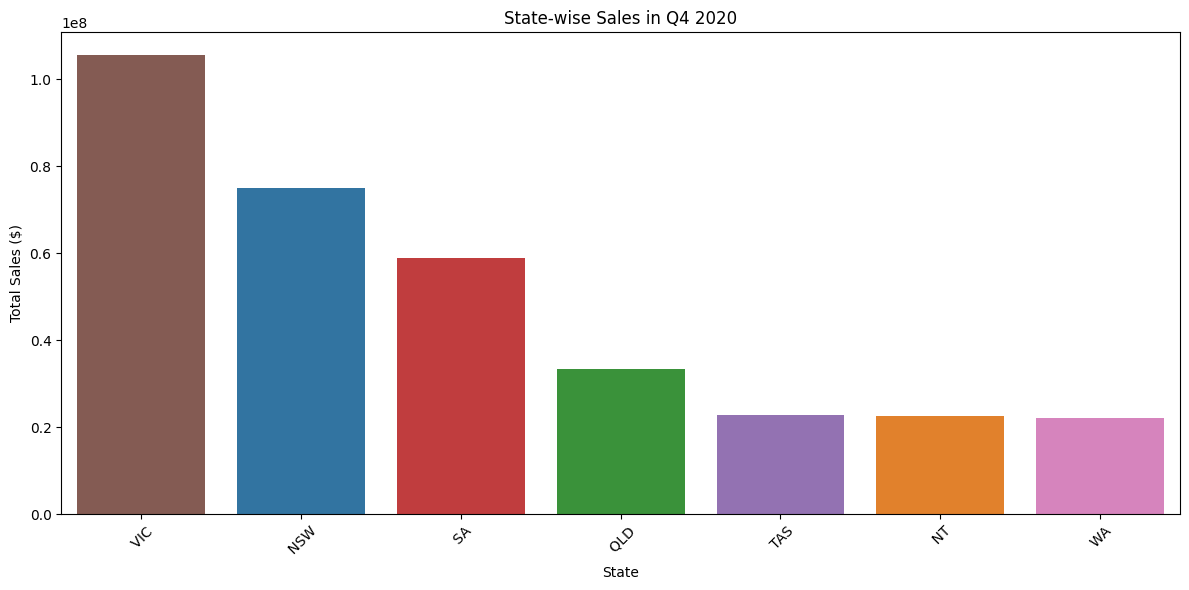

In [69]:

# Reset index so 'State' becomes a column
quarterly_report_reset = quarterly_report.reset_index()
display(quarterly_report_reset.sort_values(by='Sales', ascending=False,))


# Sort by Sales
sorted_states = quarterly_report_reset.sort_values(by='Sales', ascending=False)['State']

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=quarterly_report_reset, x='State', y='Sales', order=sorted_states, hue='State')
plt.title('State-wise Sales in Q4 2020')
plt.ylabel('Total Sales ($)')
plt.xlabel('State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




### Q4 2020 State-wise Sales Performance

### Revenue Breakdown
| State       | Total Sales   | Performance Tier | Key Insight                     |
|-------------|---------------|------------------|---------------------------------|
| **VIC**     | $105.57M      | Market Leader    | Dominant market presence        |
| **NSW**     | $74.97M       | Strong Performer | Consistent high volume          |
| **SA**      | $58.86M       | Strong Performer | Reliable revenue stream         |
| **QLD**     | $33.42M       | Growth Target    | Moderate performance            |
| **WA**      | ~$23M         | Development Zone | Underdeveloped potential        |
| **TAS**     | ~$22M         | Development Zone | Requires strategic investment   |
| **NT**      | ~$22M         | Development Zone | Lowest sales volume             |

### Key Observations
#### Top Performers
- **Victoria (VIC)**  
  - Clear market leader with **$105.57M** sales  
  - Potential saturation - focus on retention over expansion  

- **New South Wales (NSW) & South Australia (SA)**  
  - Combined **$133.83M** (45% of total revenue)  
  - Maintain current operational strategies  

#### Growth Opportunities
- **Queensland (QLD)**  
  - Mid-tier performance (**$33.42M**)  
  - Prime candidate for targeted marketing campaigns  

- **Underperforming States (WA/TAS/NT)**  
  - Collective sales just **~$67M** (22% of VIC alone)  
  

### Strategic Recommendations
1. **Resource Allocation**  
   - Shift **15-20%** of VIC's marketing budget to WA/TAS/NT  
   - Pilot 2-3 pop-up stores in QLD urban centers  

2. **Campaign Focus**  
   - VIC: Customer loyalty programs  
   - QLD: Competitive pricing strategies  
   - WA/TAS/NT: Brand awareness initiatives  



Monthly Report

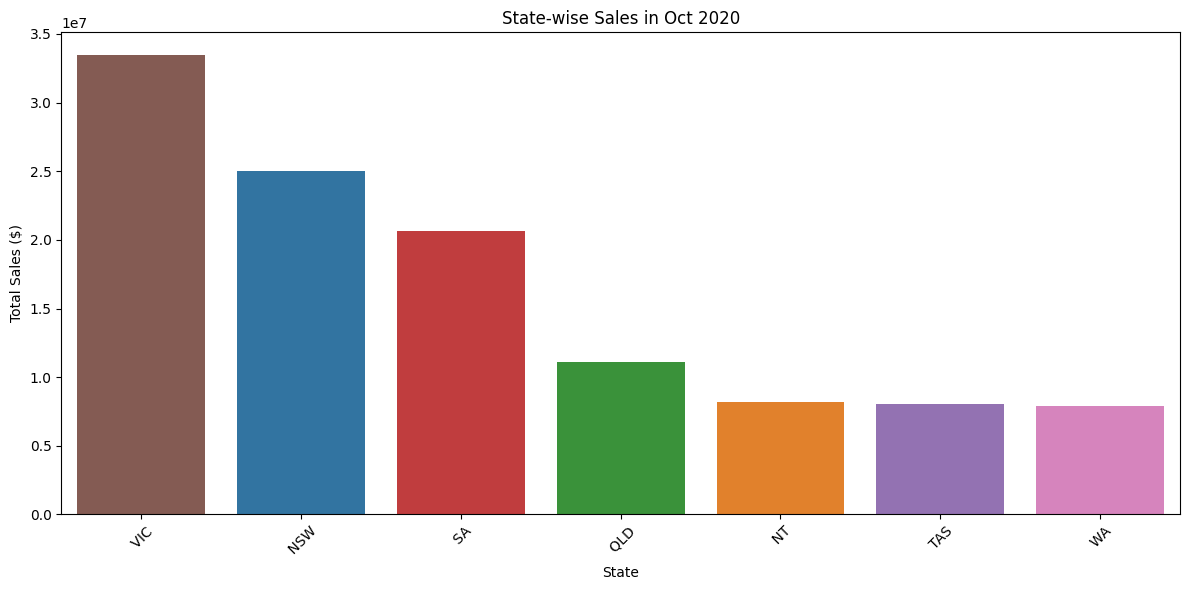

,Date,State,Sales,Unit
5,2020-10-31,VIC,33442500,13377
0,2020-10-31,NSW,25007500,10003
3,2020-10-31,SA,20610000,8244
2,2020-10-31,QLD,11120000,4448
1,2020-10-31,NT,8222500,3289
4,2020-10-31,TAS,8015000,3206
6,2020-10-31,WA,7872500,3149


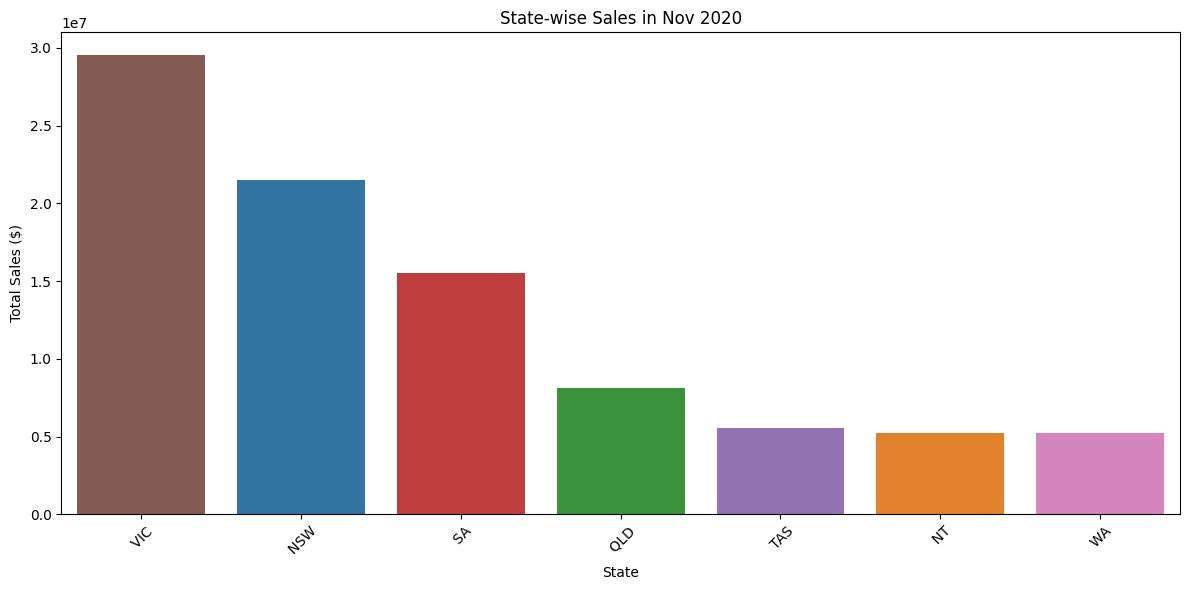

,Date,State,Sales,Unit
12,2020-11-30,VIC,29530000,11812
7,2020-11-30,NSW,21490000,8596
10,2020-11-30,SA,15532500,6213
9,2020-11-30,QLD,8110000,3244
11,2020-11-30,TAS,5545000,2218
8,2020-11-30,NT,5257500,2103
13,2020-11-30,WA,5217500,2087


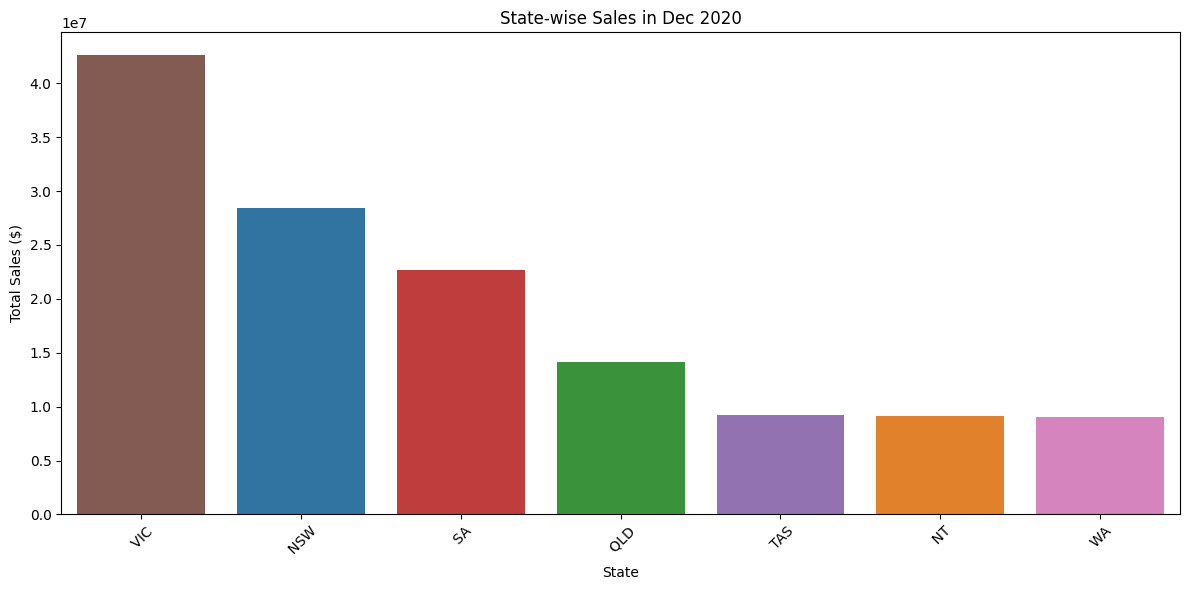

,Date,State,Sales,Unit
19,2020-12-31,VIC,42592500,17037
14,2020-12-31,NSW,28472500,11389
17,2020-12-31,SA,22715000,9086
16,2020-12-31,QLD,14187500,5675
18,2020-12-31,TAS,9200000,3680
15,2020-12-31,NT,9100000,3640
20,2020-12-31,WA,9062500,3625


,Date,Sales
2,2020-12-31,135330000
0,2020-10-31,114290000
1,2020-11-30,90682500


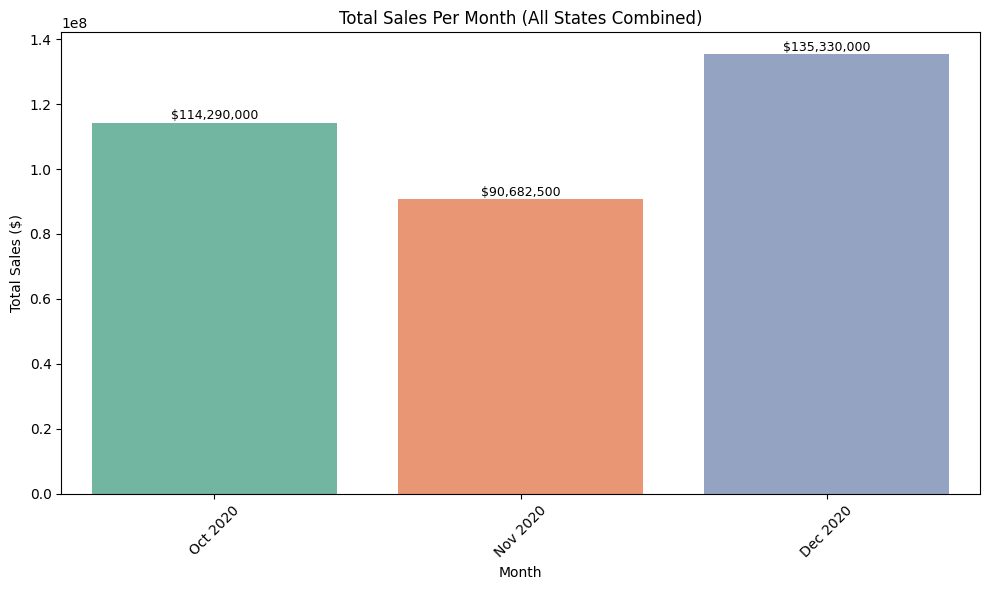

In [70]:

monthly_report_reset = monthly_report.reset_index()

months = monthly_report_reset['Date'].dt.strftime('%b %Y').unique()

for month in months:
    month_data = monthly_report_reset[monthly_report_reset['Date'].dt.strftime('%b %Y') == month]
    
    sorted_states = month_data.sort_values(by='Sales', ascending=False)['State']
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=month_data, x='State', y='Sales', order=sorted_states, hue='State')
    plt.title(f'State-wise Sales in {month}')
    plt.ylabel('Total Sales ($)')
    plt.xlabel('State')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    display(month_data.sort_values(by='Sales', ascending=False))

monthly_totals = monthly_report_reset.groupby('Date')[['Sales']].sum().reset_index()

display(monthly_totals.sort_values(by='Sales', ascending=False))    


monthly_totals['Month'] = monthly_totals['Date'].dt.strftime('%b %Y')

plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_totals, x='Month', y='Sales', palette='Set2' , hue='Month')

plt.title('Total Sales Per Month (All States Combined)')
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()

for index, row in monthly_totals.iterrows():
    plt.text(index, row['Sales'] + 50000, f"${row['Sales']:,}", 
             ha='center', va='bottom', fontsize=9)

plt.show()


# Monthly Sales Analysis – Q4 2020

---

### October 2020 – Steady Baseline  
- **Total revenue**: $114.29M  
- **Top performing states**:  
  - Victoria (VIC): $33.44M  
  - New South Wales (NSW): $25.01M  
  - South Australia (SA): $20.61M  
- **Emerging markets**:  
  - Western Australia (WA): $7.87M  
  - Tasmania (TAS): $8.02M  
  - Northern Territory (NT): $8.22M  
- **Role**: Established quarterly performance baseline  

---

###  November 2020 – Operational Challenge  
- **Total revenue**: $90.68M ▼ (20.7% MoM drop)  
- **Key observations**:  
  - VIC dipped below $30M threshold  
  - WA/TAS/NT fell below $5.5M each  
- **Potential drivers**:  
  - Pre-holiday consumer spending hesitation  
  - Inventory shortages post-October surge  

---

###  December 2020 – Seasonal Surge  
- **Total revenue**: $135.33M ▲ (49.3% MoM growth)  
- **Market highlights**:  
  - VIC: $42.59M (31.5% of monthly total)  
  - NSW: $28.47M | SA: $22.72M  
  - WA/TAS/NT: Record highs ($7.9M-$9.1M)  
- **Growth drivers**:  
  - Holiday bonuses & gift purchases  
  - Effective promotional campaigns  

---

##  Quarterly Performance Patterns  
#### **Seasonal Cycle**  
1. October: Baseline establishment  
2. November: Strategic recalibration period  
3. December: Peak performance window  

#### **Regional Leadership**  
- **VIC**: Maintained dominance (35% avg quarterly contribution)  
- **NSW/SA**: Consistent secondary performers (20-25% combined contribution)  
- **WA/TAS/NT**: December growth potential identified (15% collective Q4 share)  

---

##  Strategic Recommendations  

###  Inventory Optimization  
- Increase December-focused stock by 30% in November  
- Maintain safety stock for VIC/NSW through Q4  

###  Campaign Management  
- Launch "Pre-Holiday Blitz" offers in late November  
- Implement loyalty rewards for December repeat buyers  

###  Emerging Market Strategy  
| Region | Growth Potential | Action Plan |  
|--------|------------------|-------------|  
| **WA** | 16% Dec growth   | Boost digital marketing spend |  
| **NT** | 73% Dec surge    | Partner with local retailers |  
| **TAS** | 66% MoM jump   | Test pop-up store concept |  



In [71]:
weekly_report_reset = weekly_report.reset_index()

weekly_report_reset['Week'] = weekly_report_reset['Date'].dt.strftime('%d %b %Y')

weeks = weekly_report_reset['Week'].unique()

for week in weeks:
    week_data = weekly_report_reset[weekly_report_reset['Week'] == week]
    
    sorted_states = week_data.sort_values(by='Sales', ascending=False)
    
    print(f" Weekly Sales Summary – Week Starting {week}")
    display(sorted_states[['State', 'Sales', 'Unit']])


 Weekly Sales Summary – Week Starting 04 Oct 2020


,State,Sales,Unit
5,VIC,4355000,1742
0,NSW,3382500,1353
3,SA,2542500,1017
2,QLD,1627500,651
1,NT,1052500,421
4,TAS,1052500,421
6,WA,1032500,413


 Weekly Sales Summary – Week Starting 11 Oct 2020


,State,Sales,Unit
12,VIC,7865000,3146
7,NSW,5892500,2357
10,SA,4942500,1977
9,QLD,2545000,1018
11,TAS,1947500,779
8,NT,1937500,775
13,WA,1872500,749


 Weekly Sales Summary – Week Starting 18 Oct 2020


...

,State,Sales,Unit
82,VIC,9932500,3973
77,NSW,6647500,2659
80,SA,5417500,2167
79,QLD,3277500,1311
78,NT,2232500,893
81,TAS,2142500,857
83,WA,2005000,802


 Weekly Sales Summary – Week Starting 27 Dec 2020


,State,Sales,Unit
89,VIC,10345000,4138
84,NSW,6522500,2609
87,SA,5220000,2088
86,QLD,3410000,1364
88,TAS,2147500,859
90,WA,2092500,837
85,NT,2032500,813


 Weekly Sales Summary – Week Starting 03 Jan 2021


,State,Sales,Unit
96,VIC,4190000,1676
91,NSW,2970000,1188
94,SA,2312500,925
93,QLD,1460000,584
95,TAS,1002500,401
92,NT,932500,373
97,WA,925000,370


In [72]:
weekly_totals = weekly_report_reset.groupby('Date')[['Sales']].sum().reset_index()

weekly_totals['Week'] = weekly_totals['Date'].dt.strftime('%d %b %Y')

weekly_totals_sorted = weekly_totals.sort_values(by='Sales', ascending=False)

print("Weekly Total Sales (All States Combined) – Sorted Descending")
display(weekly_totals_sorted[['Week', 'Sales']])


Weekly Total Sales (All States Combined) – Sorted Descending


,Week,Sales
12,27 Dec 2020,31770000
11,20 Dec 2020,31655000
10,13 Dec 2020,31525000
9,06 Dec 2020,29622500
1,11 Oct 2020,27002500
3,25 Oct 2020,26815000
2,18 Oct 2020,26640000
4,01 Nov 2020,21807500
8,29 Nov 2020,21477500
6,15 Nov 2020,21172500


<Figure size 1400x700 with 0 Axes>

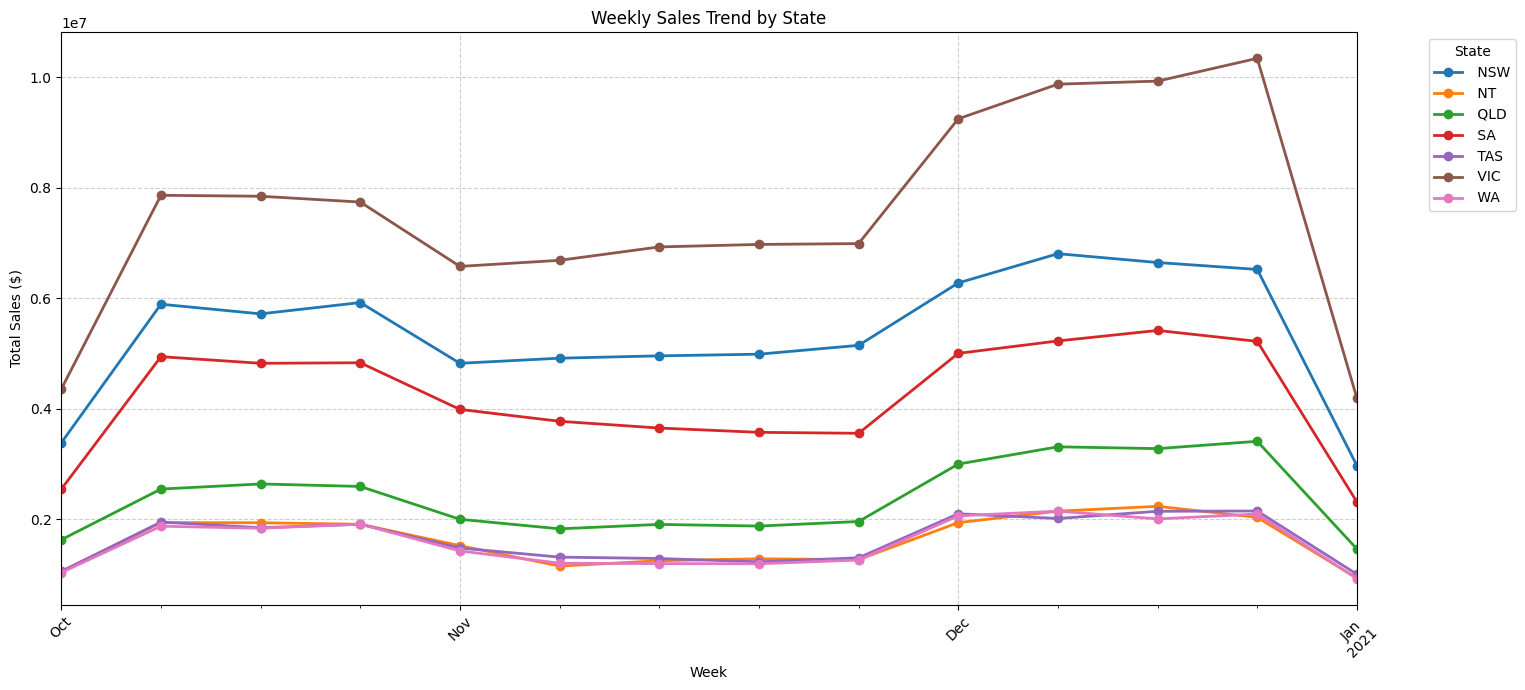

In [73]:
weekly_sales_pivot = weekly_report_reset.pivot_table(
    index='Date',
    columns='State',
    values='Sales',
    aggfunc='sum'
).sort_index()

plt.figure(figsize=(14, 7))
weekly_sales_pivot.plot(marker='o', figsize=(14, 7), linewidth=2)

plt.title('Weekly Sales Trend by State')
plt.ylabel('Total Sales ($)')
plt.xlabel('Week')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


###  Weekly Sales Performance – Q4 2020

####  Sales Overview
- Weekly totals ranged from **$13.8M to $31.8M**
- Sales **steadily climbed through December**, peaking just before Christmas
- Notable **dip in early January** — likely post-holiday fatigue or depleted household budgets

####  Trend Highlights
- **Consistent Upward Trajectory in December**: Sales rose sharply each week until the final December peak
- **Final Weeks of December** (13th–27th): All states saw synchronized growth, aligning with seasonal shopping trends and bonus disbursements
- **Sharp Decline in January**: Week of **3 Jan 2021** had the lowest performance — indicating demand saturation

####  State-wise Observations
- **VIC**: Clear leader across all weeks — its line consistently tracked **well above** others
- **NSW**: Strong and stable second — shadowed VIC but maintained distance from mid-tier states
- **SA**: Reliable third place most weeks
- **QLD**: Mid-tier — typically between $8M–$14M weekly, never reaching top 3
- **WA, TAS, NT**: Consistently clustered at the bottom, their sales lines nearly overlapping with minor interchanges

####  Key Insights
1. **Sales are seasonally driven**, not weekly reactive — surges coincide with **late-month and holiday events**
2. **VIC’s dominance** suggests it is saturated; little room for major growth, but requires **maintenance strategies**
3. **Lower-tier states (WA, TAS, NT)** have consistent underperformance — but also low volatility, possibly steady demand
4. **Synchronized patterns across states** indicate a **national behavior trend**, likely driven by macroeconomic or cultural factors

---

###  Strategic Implications
- **Focus campaigns on monthly timing** (e.g., end-of-month surges), not weekly fluctuations
- **Leverage December behavior** to plan yearly peak campaigns (e.g., pre-Christmas boosts)
- Consider **pilot promotions in QLD**, where performance is variable — a responsive market may exist
- Use weekly data for **logistics planning**, such as:
  - Inventory staging before expected surges
  - Aligning staff availability with anticipated traffic


####  State-wise Observations
- **VIC**: Market leader throughout Q4, but experienced the **sharpest drop in the final week of December**, narrowing its lead over NSW — suggests a vulnerability during peak fatigue or logistical stress
- **NSW**: Stable second, and **benefited relatively** from VIC's drop in the last week
- **SA**: Solid third place with consistent weekly output
- **QLD**: Mid-tier state — minor fluctuations, but no standout growth moments
- **WA, TAS, NT**: Performed similarly throughout, forming a low-volume cluster with overlapping trajectories
- **All States**: Displayed a **coordinated decline in the last week of December**, likely due to:
  - Budget exhaustion post-holiday shopping
  - Reduced store hours
  - General consumer burnout

---

###  Strategic Recommendations for Growth

1. **Leverage Seasonal Momentum**  
   - Double down on early-to-mid December campaigns while momentum is high  
   - Introduce “soft landing” promotions in the last week to avoid steep drops  

2. **Support Underperforming States**  
   - Pilot regional offers in **WA, TAS, and NT**  
   - Increase local brand presence through geo-targeted digital ads  

3. **Activate Mid-Quarter Promotions**  
   - Use early November and mid-October dips as timing signals for flash sales or limited-time bundles  

4. **Optimize Inventory & Staffing**  
   - Prepare for end-of-quarter volatility by securing **VIC’s** logistics capacity  
   - Implement dynamic resourcing for high-load periods (e.g., rotating shifts, predictive stocking)

5. **Balance the Load Between VIC & NSW**  
   - Explore **shared campaign efforts** or partial redistributions of VIC demand to NSW  
   - Ensure VIC doesn’t become a **single point of failure** during peak traffic

6. **Monitor Year-End Buyer Fatigue**  
   - Adjust messaging in late December to address emotional exhaustion (“treat yourself” campaigns, lighter tones)  
   - Maintain visibility without over-selling — focus on retention and gentle engagement  


In [74]:

app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Retail Sales Dashboard", style={'textAlign': 'center'}),
    
    html.Div([
        dcc.Dropdown(
            id='state-filter',
            options=[{'label': state, 'value': state} for state in data['State'].unique()],
            multi=True,
            placeholder="Select States"
        ),
        dcc.Dropdown(
            id='group-filter',
            options=[{'label': group, 'value': group} for group in data['Group'].unique()],
            multi=True,
            placeholder="Select Demographic Groups"
        )
    ], style={'width': '80%', 'margin': '0 auto'}),
    
    html.Div([
        dcc.Graph(id='state-sales-bar'),
        dcc.Graph(id='group-sales-box')
    ], style={'display': 'grid', 'gridTemplateColumns': 'repeat(2, 1fr)'}),
    
    html.Div([
        dcc.Graph(id='time-analysis-line')
    ], style={'marginTop': '20px'})
])

@app.callback(
    [Output('state-sales-bar', 'figure'),
     Output('group-sales-box', 'figure'),
     Output('time-analysis-line', 'figure')],
    [Input('state-filter', 'value'),
     Input('group-filter', 'value')]
)
def update_figures(selected_states, selected_groups):
    filtered_data = data.copy()
    
    if selected_states:
        filtered_data = filtered_data[filtered_data['State'].isin(selected_states)]
    if selected_groups:
        filtered_data = filtered_data[filtered_data['Group'].isin(selected_groups)]
    
    fig1 = px.bar(
        filtered_data,
        x='State',
        y='Sales',
        color='Group',
        barmode='group',
        title='State-wise Sales by Demographic Group',
        labels={'Sales': 'Total Sales ($)'},
        height=800
    )
    
    fig2 = px.box(
        filtered_data,
        x='Group',
        y='Sales',
        color='State',
        title='Group-wise Sales Distribution',
        labels={'Sales': 'Sales Amount ($)'},
        height=800
    )
    
    fig3 = px.line(
        filtered_data.groupby(['Date', 'Group'])['Sales'].sum().reset_index(),
        x='Date',
        y='Sales',
        color='Group',
        title='Sales Trend Over Time',
        labels={'Sales': 'Total Sales ($)'},
        height=800
    )
    
    
    return fig1, fig2, fig3

app.run(debug=True, port=8050) 


### Visualization Package Recommendation  
**Recommended Tool**: Plotly (with Dash Framework)  

**Key Reasons for Selection**:  
1. **Interactive Capabilities**:  
   - Enables hover tooltips, zooming, and dynamic filtering  
   - Supports real-time updates through Dash callbacks  

2. **Cross-Platform Compatibility**:  
   - Renders perfectly in Jupyter notebooks during development  
   - Deploys seamlessly to web browsers via Dash for end-user access  

3. **Multi-Chart Coordination**:  
   - Linked interactions between charts (filter once, update all)  
   - Shared legend and color consistency across visualizations  

4. **Project-Specific Advantages**:  
   - Handles large state/demographic groupings without performance loss  
   - Built-in date/time handling for temporal analysis  
   - Automatic responsive design for different screen sizes  

**Other Packages used**:  
- **Matplotlib and Seaborn**: They were used on static charts, lack required interactivity  
 